In [ ]:
# importing necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from src.data import load_student_data, create_target

sns.set_theme(style="whitegrid")

In [ ]:
# SECTION 1: DATASET OVERVIEW
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

df_raw = load_student_data()
df = create_target(df_raw)

df.head()  # confirming dataset uploaded successfully
df.shape  # checking size of dataset
df.columns  # checking the columns
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

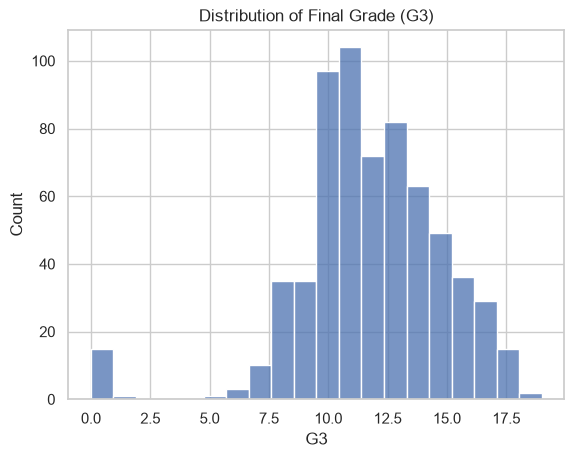

In [ ]:
# SECTION 2: DATA QUALITY CHECK
print("Dataset shape:", df_raw.shape)
print("Missing values by column:")
print(df_raw.isnull().sum())  # checking for missing values
print(
    "Exact duplicate rows:", df_raw.duplicated().sum()
)  # checking for duplicated values
display(df_raw.describe(include="all"))
print("G3 summary:")
print(df_raw["G3"].describe())  # mathematical description of g3
print("G3 value counts:")
print(df_raw["G3"].value_counts().sort_index())

sns.histplot(df["G3"], bins=20)
plt.title("Distribution of Final Grade (G3)")
plt.show()

Target Counts:
 target
1    549
0    100
Name: count, dtype: int64

Target Proportion:
 target
1    84.59168
0    15.40832
Name: proportion, dtype: float64


C:\Users\boham\AppData\Local\Temp\ipykernel_56332\3069545387.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette=["#e74c3c", "#2ecc71"])


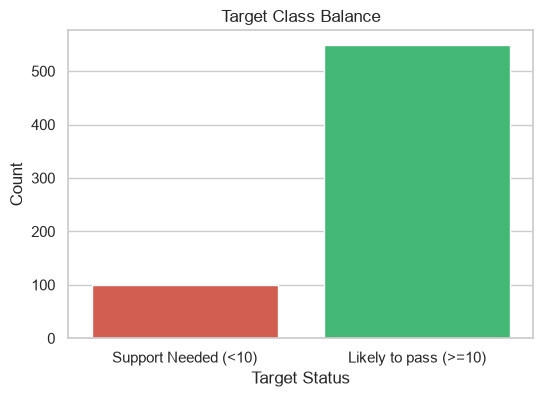

In [ ]:
df["needs_support"] = (df["G3"] >= 10).astype(int)

print("Target Counts:\n", df["needs_support"].value_counts())
print("\nTarget Proportion:\n", df["needs_support"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x="needs_support", data=df, palette=["#e74c3c", "#2ecc71"])
plt.xticks([1, 0], ["Support Needed (<10)", "Likely to pass (>=10)"])
plt.title("Target Class Balance")
plt.xlabel("Target Status")
plt.ylabel("Count")
plt.show()

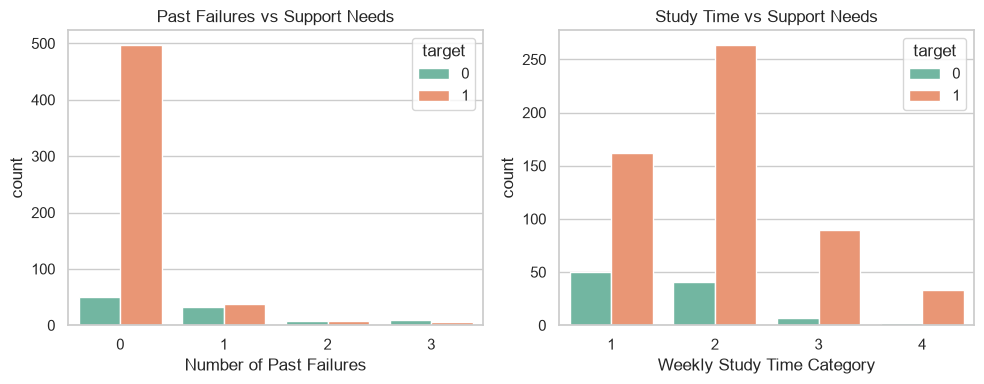

In [ ]:
# TASK 3
plt.figure(figsize=(10, 4))

# past failures vs target status
plt.subplot(1, 2, 1)
sns.countplot(x="failures", hue="target", data=df, palette="Set2")
plt.title("Past Failures vs Support Needs")
plt.xlabel("Number of Past Failures")

# weekly study time vs target status
plt.subplot(1, 2, 2)
sns.countplot(x="studytime", hue="target", data=df, palette="Set2")
plt.title("Study Time vs Support Needs")
plt.xlabel("Weekly Study Time Category")

plt.tight_layout()
plt.show()

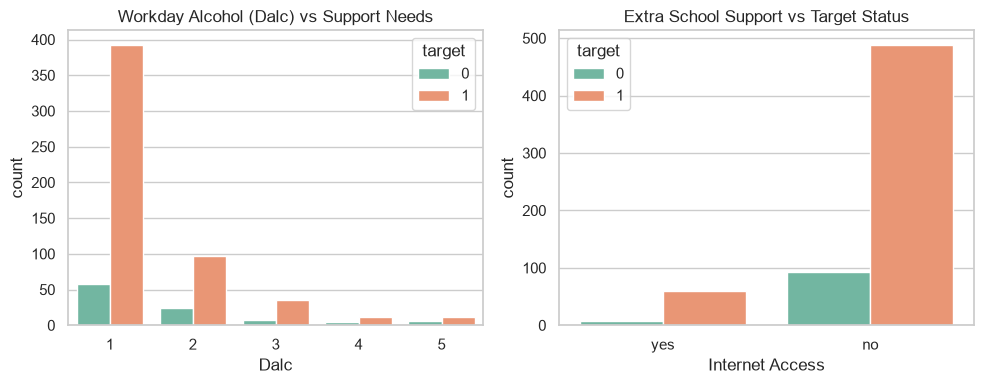

In [ ]:
plt.figure(figsize=(10, 4))

# Workday alcohol consumption (dalc) vs target
plt.subplot(1, 2, 1)
sns.countplot(x="Dalc", hue="target", data=df, palette="Set2")
plt.title("Workday Alcohol (Dalc) vs Support Needs")

# school support vs target
plt.subplot(1, 2, 2)
sns.countplot(x="schoolsup", hue="target", data=df, palette="Set2")
plt.title("Extra School Support vs Target Status")
plt.xlabel("Internet Access")

plt.tight_layout()
plt.show()

Correlations with Target:
 target        1.000000
G3            0.663157
G2            0.592251
G1            0.563070
studytime     0.165111
Fedu          0.146249
Medu          0.144803
famrel        0.044987
health       -0.009979
traveltime   -0.057869
goout        -0.067241
absences     -0.087483
freetime     -0.093349
age          -0.110722
Walc         -0.116249
Dalc         -0.123627
failures     -0.380237
Name: target, dtype: float64


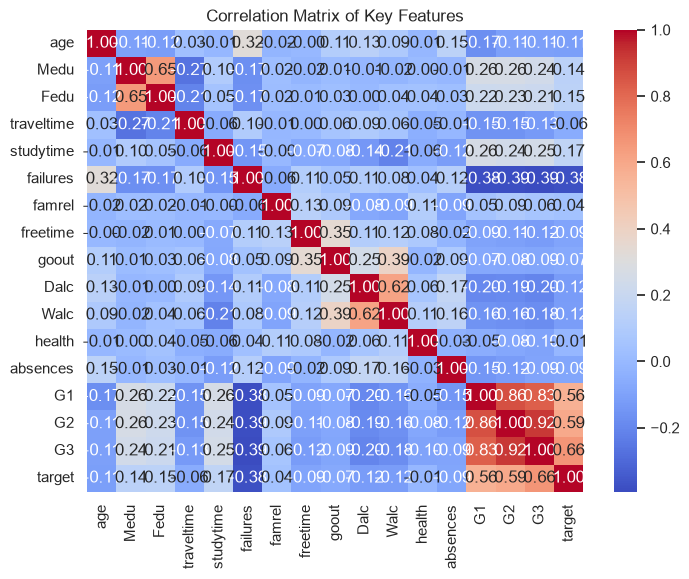

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
correlations = numeric_df.corr()["target"].sort_values(ascending=False)

print("Correlations with Target:\n", correlations)

plt.figure(figsize=(8, 6))
key_cols = ["target", "G1", "G2", "studytime", "failures", "Dalc", "absences", "age"]
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Key Features")
plt.show()

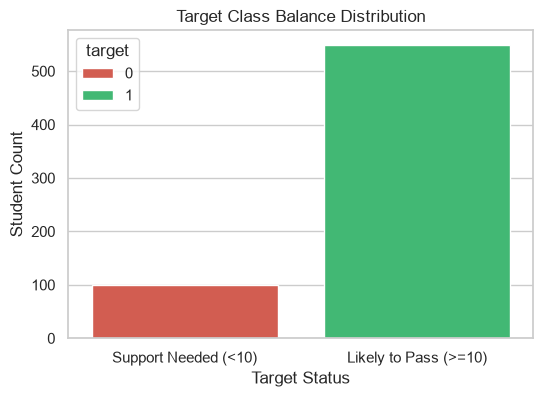

In [ ]:
# TASK 4: Prepare EDA charts and findings
# ensuring output directory exists
os.makedirs("reports/figures", exist_ok=True)

# CHART 1: Target Class Balance
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="target", hue="target", data=df, palette=["#e74c3c", "#2ecc71"])
plt.xticks([0, 1], ["Support Needed (<10)", "Likely to Pass (>=10)"])
plt.title("Target Class Balance Distribution")
plt.xlabel("Target Status")
plt.ylabel("Student Count")
plt.savefig("reports/figures/01_class_balance.png", dpi=300, bbox_inches="tight")
plt.show()


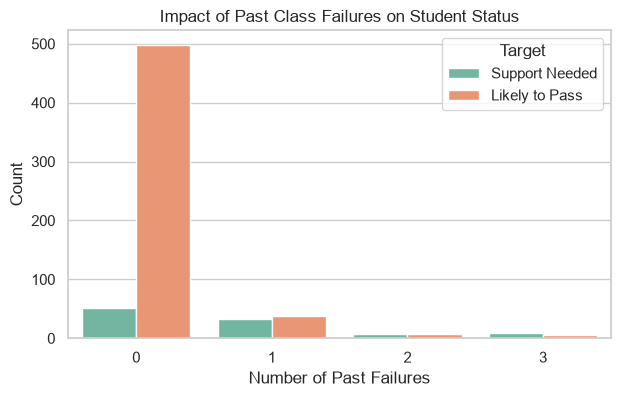

In [ ]:
# CHART 2: Past Failures vs Support Needs
plt.figure(figsize=(7, 4))
sns.countplot(x="failures", hue="target", data=df, palette="Set2")
plt.title("Impact of Past Class Failures on Student Status")
plt.xlabel("Number of Past Failures")
plt.ylabel("Count")
plt.legend(title="Target", labels=["Support Needed", "Likely to Pass"])
plt.savefig("reports/figures/02_failures_vs_target.png", dpi=300, bbox_inches="tight")
plt.show()

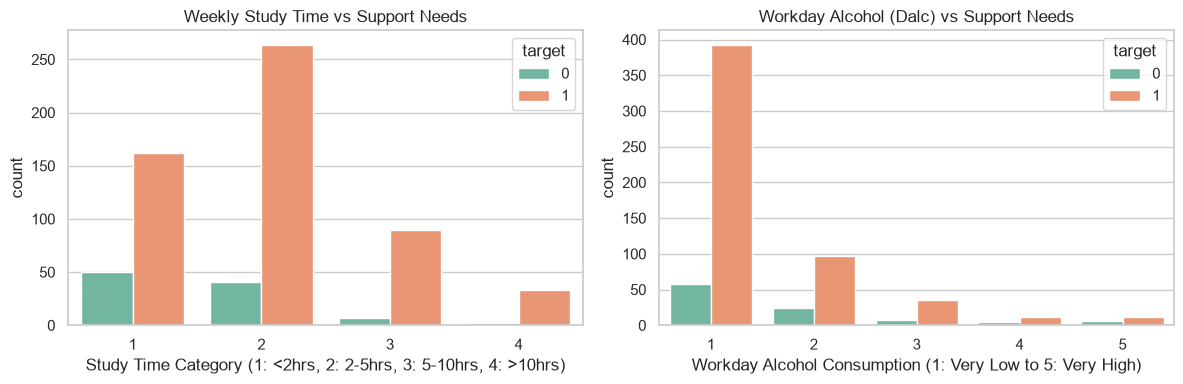

In [ ]:
# CHART 3: Study Time & Alcohol Consumption Impact
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="studytime", hue="target", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Weekly Study Time vs Support Needs")
axes[0].set_xlabel("Study Time Category (1: <2hrs, 2: 2-5hrs, 3: 5-10hrs, 4: >10hrs)")

sns.countplot(x="Dalc", hue="target", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Workday Alcohol (Dalc) vs Support Needs")
axes[1].set_xlabel("Workday Alcohol Consumption (1: Very Low to 5: Very High)")

plt.tight_layout()
plt.savefig("reports/figures/03_lifestyle_factors.png", dpi=300, bbox_inches="tight")
plt.show()

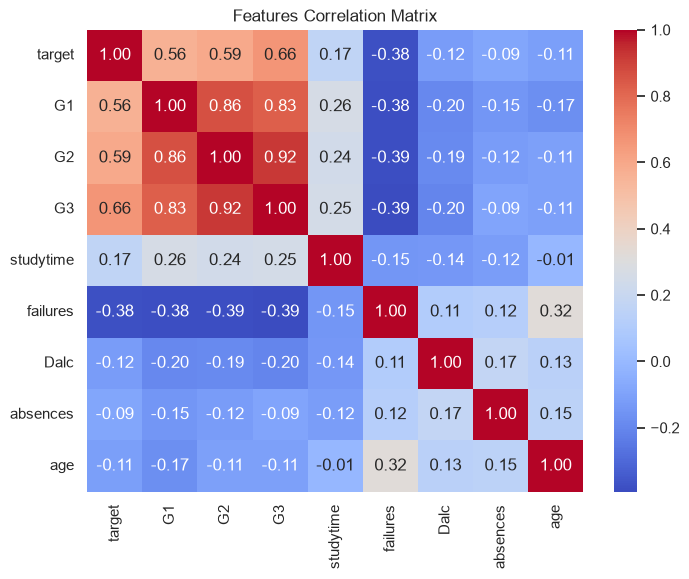

In [ ]:
# CHART 4: Correlation Matrix
plt.figure(figsize=(8, 6))
key_cols = [
    "target",
    "G1",
    "G2",
    "G3",
    "studytime",
    "failures",
    "Dalc",
    "absences",
    "age",
]
sns.heatmap(df[key_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Features Correlation Matrix")
plt.savefig("reports/figures/04_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()